# 09 · Múi giờ theo vị trí

**Câu hỏi:** File `.plt` lưu giờ **GMT**. Pipeline hiện đổi mọi điểm sang **UTC+8** (Bắc Kinh). Với các điểm ở nước ngoài, giờ địa phương này có sai không, sai bao nhiêu, và nên sửa thế nào?

**Vì sao quan trọng:** bộ phát hiện stay-point chỉ dùng *khoảng* thời gian, nên không bị ảnh hưởng. Nhưng mọi bước dùng **giờ trong ngày** thì bị ảnh hưởng: định nghĩa "đêm" (notebook 04) và classifier Home/Office. Một người ở Seattle ngủ lúc 23h giờ địa phương sẽ bị ghi là đang ở lúc 14h hoặc 15h giờ Bắc Kinh, nên đêm ở nhà có thể bị coi là giờ làm việc.

**Cách sửa được kiểm chứng:** tra múi giờ IANA từ toạ độ bằng `timezonefinder` (offline, tra điểm trong đa giác ranh giới múi giờ), rồi đổi GMT sang giờ địa phương bằng `zoneinfo`, có xử lý giờ mùa hè (DST). Không suy từ kinh độ (15° một giờ), vì Trung Quốc trải qua khoảng 5 múi giờ địa lý nhưng chỉ dùng một giờ chính thức, và cách đó không có DST.

**Khái niệm:**
- *Lệch múi giờ* (`affected`): điểm mà độ lệch UTC thật tại thời điểm đó **khác +8 h**. Đài Loan, Hồng Kông, Singapore cũng là +8 nên không bị tính là lệch.
- *Giờ hoạt động* (`active hour`): một cặp (user, ngày, giờ) có ít nhất một điểm GPS. Đếm theo giờ hoạt động thay vì theo số điểm, để user ghi dày (1 giây một điểm) không lấn át user ghi thưa.

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

NOTEBOOK = "09_timezone_by_location"
DATA_DIR = Path("../data/raw")
OUT_DIR = Path("outputs") / NOTEBOOK
FIG_DIR, TABLE_DIR, CACHE_DIR, MAP_DIR = (OUT_DIR / d for d in ("figures", "tables", "cache", "maps"))
for d in (FIG_DIR, TABLE_DIR, CACHE_DIR, MAP_DIR):
    d.mkdir(parents=True, exist_ok=True)

sys.path.insert(0, str(Path("../src").resolve()))
from timezonefinder import TimezoneFinder

USERS_DIR = Path("../data/processed/users")
FIXED_OFFSET_H = 8
CELL_DECIMALS = 2   # timezone lookup on a 0.01 deg grid (~1 km); borders are never crossed inside a city block
STAYS_PATH = Path("outputs/04_file_boundaries/cache/staypoints_per_file_vs_chained_18h.parquet")
tf = TimezoneFinder()


def tz_of(lat: np.ndarray, lon: np.ndarray, cache: dict) -> np.ndarray:
    """IANA timezone per point, looked up once per grid cell."""
    keys = list(zip(np.round(lat, CELL_DECIMALS), np.round(lon, CELL_DECIMALS)))
    for k in set(keys) - cache.keys():
        cache[k] = tf.timezone_at(lat=k[0], lng=k[1]) or "Etc/UTC"
    return np.array([cache[k] for k in keys], dtype=object)


def local_time(utc: pd.Series, tz: pd.Series) -> pd.Series:
    """Naive local wall-clock time of GMT timestamps, each in its own timezone (DST aware)."""
    out = pd.Series(pd.NaT, index=utc.index, dtype="datetime64[ns]")
    aware = utc.dt.tz_localize("UTC")
    for name, idx in tz.groupby(tz).groups.items():
        out.loc[idx] = aware.loc[idx].dt.tz_convert(name).dt.tz_localize(None)
    return out

## 1. Gán múi giờ cho mọi điểm
Với mỗi user: tra múi giờ từng điểm, tính giờ địa phương theo hai cách (UTC+8 cố định và theo vị trí), rồi chỉ giữ các bảng tổng hợp (số điểm theo múi giờ, giờ hoạt động, file đổi múi giờ). Kết quả được cache.

In [2]:
AGG_PATH = CACHE_DIR / "tz_aggregates.parquet"
HOURS_PATH = CACHE_DIR / "active_hours.parquet"
FILES_PATH = CACHE_DIR / "files_tz.parquet"
if AGG_PATH.exists():
    agg, active, files_tz = pd.read_parquet(AGG_PATH), pd.read_parquet(HOURS_PATH), pd.read_parquet(FILES_PATH)
else:
    cache, aggs, hours, files = {}, [], [], []
    for path in sorted(USERS_DIR.glob("user_*.parquet")):
        uid = path.stem.split("_")[1]
        df = pd.read_parquet(path, columns=["source_file", "datetime", "lat", "lon"])
        df["tz"] = tz_of(df["lat"].to_numpy(), df["lon"].to_numpy(), cache)
        df["local_true"] = local_time(df["datetime"], df["tz"])
        df["local_fixed"] = df["datetime"] + pd.Timedelta(hours=FIXED_OFFSET_H)
        df["offset_h"] = (df["local_true"] - df["datetime"]).dt.total_seconds() / 3600
        df["affected"] = df["offset_h"] != FIXED_OFFSET_H
        aggs.append(df.groupby(["tz", "offset_h"]).size().rename("n_points").reset_index().assign(user_id=uid))
        for method in ("local_true", "local_fixed"):
            slot = df[method].dt.floor("h")
            h = pd.DataFrame({"affected": df["affected"], "slot": slot}).drop_duplicates()
            hours.append(h.assign(hour=h["slot"].dt.hour, method=method, user_id=uid).drop(columns="slot"))
        f = df.groupby("source_file").agg(n_offsets=("offset_h", "nunique"), n_tz=("tz", "nunique"),
                                          affected_share=("affected", "mean"))
        files.append(f.reset_index().assign(user_id=uid))
    agg, active, files_tz = pd.concat(aggs, ignore_index=True), pd.concat(hours, ignore_index=True), pd.concat(files, ignore_index=True)
    agg.to_parquet(AGG_PATH)
    active.to_parquet(HOURS_PATH)
    files_tz.to_parquet(FILES_PATH)

total = agg["n_points"].sum()
affected_pts = agg.loc[agg["offset_h"] != FIXED_OFFSET_H, "n_points"].sum()
print(f"Points: {total:,} | affected (true offset != +8 h): {affected_pts:,} ({affected_pts / total:.2%})")

Points: 24,177,446 | affected (true offset != +8 h): 629,980 (2.61%)


## 2. Phạm vi: múi giờ nào, user nào, file nào
`share_affected` là tỉ lệ số điểm của user có độ lệch UTC khác +8 h.

In [3]:
by_tz = (agg.groupby(["tz", "offset_h"])["n_points"].sum().reset_index()
         .assign(share=lambda d: d["n_points"] / total).sort_values("n_points", ascending=False))
by_tz.to_csv(TABLE_DIR / "points_by_timezone.csv", index=False)

by_user = agg.assign(affected=agg["offset_h"] != FIXED_OFFSET_H).groupby("user_id").apply(
    lambda g: pd.Series({"n_points": g["n_points"].sum(),
                         "share_affected": g.loc[g["affected"], "n_points"].sum() / g["n_points"].sum(),
                         "main_tz": g.groupby("tz")["n_points"].sum().idxmax()}), include_groups=False)
touched = by_user[by_user["share_affected"] > 0].sort_values("share_affected", ascending=False)
touched.to_csv(TABLE_DIR / "users_outside_utc8.csv")

multi = files_tz[files_tz["n_offsets"] > 1]
print(f"Distinct timezones: {by_tz['tz'].nunique()} | users with any affected point: {len(touched)} / {len(by_user)} "
      f"| users mostly (> 50%) affected: {(touched['share_affected'] > 0.5).sum()}")
print(f"Files: {len(files_tz):,} | fully affected: {(files_tz['affected_share'] == 1).sum()} "
      f"| partly affected: {((files_tz['affected_share'] > 0) & (files_tz['affected_share'] < 1)).sum()} "
      f"| spanning more than one UTC offset (e.g. flights): {len(multi)}")
print("\nTop timezones:")
print(by_tz.head(12).round(4).to_string(index=False))
print("\nUsers with the largest affected share:")
touched.head(10).round(3)

Distinct timezones: 42 | users with any affected point: 16 / 182 | users mostly (> 50%) affected: 2
Files: 18,670 | fully affected: 215 | partly affected: 20 | spanning more than one UTC offset (e.g. flights): 23

Top timezones:
                 tz  offset_h  n_points  share
      Asia/Shanghai       8.0  23403954 0.9680
America/Los_Angeles      -7.0    148963 0.0062
America/Los_Angeles      -8.0     74172 0.0031
        Asia/Taipei       8.0     71798 0.0030
        Europe/Rome       2.0     61732 0.0026
        Asia/Urumqi       6.0     54540 0.0023
       Europe/Paris       2.0     52309 0.0022
       Asia/Bangkok       7.0     51901 0.0021
      Europe/Madrid       2.0     36772 0.0015
     Asia/Hong_Kong       8.0     30898 0.0013
    Asia/Phnom_Penh       7.0     28238 0.0012
  America/Anchorage      -8.0     26206 0.0011

Users with the largest affected share:


,n_points,share_affected,main_tz
user_id,,,
160,28238,1.000,Asia/Phnom_Penh
172,43207,0.825,America/Anchorage
082,172543,0.185,Asia/Shanghai
163,969080,0.183,Asia/Shanghai
089,30919,0.102,Asia/Shanghai
144,582832,0.101,Asia/Shanghai
142,178267,0.099,Asia/Shanghai
153,2156958,0.082,Asia/Shanghai
140,342496,0.066,Asia/Shanghai


## 3. Kiểm chứng: cách nào cho nhịp ngày đêm đúng?

Người dùng GeoLife có nhịp sinh hoạt rõ: rất ít khi ghi GPS lúc 1–5 h sáng. **Mốc so sánh** là phân bố giờ hoạt động của các điểm **không lệch** (ở vùng +8 h, giờ địa phương chắc chắn đúng).

Với các điểm **bị lệch**, tính phân bố giờ hoạt động theo hai cách:
- `fixed_utc8`: cách hiện tại;
- `by_location`: theo múi giờ của toạ độ.

Cách đúng phải cho phân bố **giống mốc**. Độ khác được đo bằng *total variation distance* (TVD, từ 0 = giống hệt tới 1 = khác hoàn toàn), kèm tỉ lệ giờ hoạt động rơi vào 1–5 h sáng.

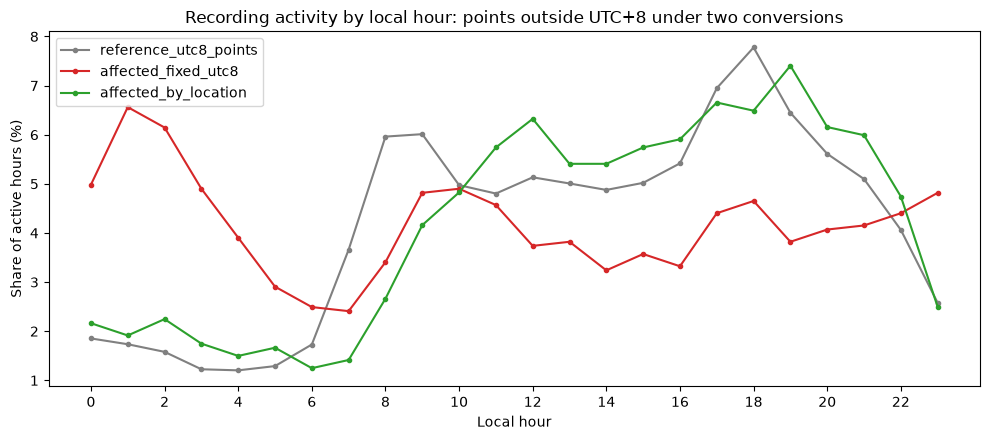

,tvd_vs_reference,share_active_01_05h
reference_utc8_points,0.000,0.057
affected_fixed_utc8,0.239,0.215
affected_by_location,0.097,0.074


In [4]:
def hour_dist(d: pd.DataFrame) -> pd.Series:
    return d["hour"].value_counts(normalize=True).reindex(range(24), fill_value=0)


reference = hour_dist(active[(active["method"] == "local_true") & ~active["affected"]])
fixed = hour_dist(active[(active["method"] == "local_fixed") & active["affected"]])
true_ = hour_dist(active[(active["method"] == "local_true") & active["affected"]])
dist = pd.DataFrame({"reference_utc8_points": reference, "affected_fixed_utc8": fixed, "affected_by_location": true_})
dist.index.name = "local_hour"
dist.to_csv(TABLE_DIR / "active_hour_distribution.csv")

NIGHT = [1, 2, 3, 4]
check = pd.DataFrame({
    "tvd_vs_reference": [0.0, 0.5 * (fixed - reference).abs().sum(), 0.5 * (true_ - reference).abs().sum()],
    "share_active_01_05h": [reference[NIGHT].sum(), fixed[NIGHT].sum(), true_[NIGHT].sum()],
}, index=dist.columns)
check.to_csv(TABLE_DIR / "timezone_method_check.csv")

ax = (dist * 100).plot(figsize=(10, 4.5), marker="o", ms=3, color=["gray", "#d62728", "#2ca02c"])
ax.set_xlabel("Local hour")
ax.set_ylabel("Share of active hours (%)")
ax.set_title("Recording activity by local hour: points outside UTC+8 under two conversions")
ax.set_xticks(range(0, 24, 2))
plt.tight_layout()
plt.savefig(FIG_DIR / "fig01_active_hours_by_method.png", dpi=150)
plt.show()
check.round(3)

## 4. Tác động lên stay-point và "đêm"
Dùng stay-point của notebook 04 (cả hai cách chạy). Múi giờ của stay-point lấy theo toạ độ tâm. Một stay-point là **đêm** khi nó kéo qua 3 giờ sáng giờ địa phương (cùng định nghĩa với notebook 04). `night_changed` là số stay-point đổi nhãn đêm/không đêm khi chuyển từ UTC+8 cố định sang múi giờ theo vị trí.

In [5]:
stays = pd.read_parquet(STAYS_PATH)
stays["tz"] = tz_of(stays["lat"].to_numpy(), stays["lon"].to_numpy(), {})
stays["offset_h"] = (local_time(stays["arrival"], stays["tz"]) - stays["arrival"]).dt.total_seconds() / 3600


def covers_3am(arr_local: pd.Series, dep_local: pd.Series) -> pd.Series:
    first = arr_local.dt.normalize() + pd.Timedelta(hours=3)
    first = first.where(first >= arr_local, first + pd.Timedelta(days=1))
    return first <= dep_local


fixed_h = pd.Timedelta(hours=FIXED_OFFSET_H)
stays["night_fixed"] = covers_3am(stays["arrival"] + fixed_h, stays["departure"] + fixed_h)
stays["night_true"] = covers_3am(local_time(stays["arrival"], stays["tz"]), local_time(stays["departure"], stays["tz"]))
impact = stays.groupby("method").apply(lambda s: pd.Series({
    "stay_points": len(s),
    "affected_stays": int((s["offset_h"] != FIXED_OFFSET_H).sum()),
    "night_fixed_utc8": int(s["night_fixed"].sum()),
    "night_by_location": int(s["night_true"].sum()),
    "night_changed": int((s["night_fixed"] != s["night_true"]).sum()),
    "users_night_changed": s.loc[s["night_fixed"] != s["night_true"], "user_id"].nunique(),
    "users_without_night_fixed": 182 - s.loc[s["night_fixed"], "user_id"].nunique(),
    "users_without_night_by_location": 182 - s.loc[s["night_true"], "user_id"].nunique(),
}), include_groups=False).T
impact.to_csv(TABLE_DIR / "night_impact.csv")
impact

method,chained,per_file
stay_points,18598,12856
affected_stays,468,408
night_fixed_utc8,3340,395
night_by_location,3344,378
night_changed,74,37
users_night_changed,8,7
users_without_night_fixed,41,96
users_without_night_by_location,40,96


### Ví dụ: các user chủ yếu ở nước ngoài
Với mỗi user có hơn 50% số điểm bị lệch: số stay-point đêm theo hai cách, và giờ đến trung vị của các stay-point.

In [6]:
abroad = touched[touched["share_affected"] > 0.5].index
ch = stays[(stays["method"] == "chained") & stays["user_id"].isin(abroad)].copy()
ch["arrival_hour_fixed"] = (ch["arrival"] + fixed_h).dt.hour
ch["arrival_hour_true"] = local_time(ch["arrival"], ch["tz"]).dt.hour
examples = ch.groupby("user_id").agg(
    main_tz=("tz", lambda s: s.value_counts().index[0]), stay_points=("tz", "size"),
    night_fixed_utc8=("night_fixed", "sum"), night_by_location=("night_true", "sum"),
    median_arrival_hour_fixed=("arrival_hour_fixed", "median"), median_arrival_hour_by_location=("arrival_hour_true", "median"))
examples.to_csv(TABLE_DIR / "abroad_user_examples.csv")
examples

,main_tz,stay_points,night_fixed_utc8,night_by_location,median_arrival_hour_fixed,median_arrival_hour_by_location
user_id,,,,,,
160,Asia/Phnom_Penh,18,2,1,10.0,17.5
172,Asia/Shanghai,22,0,1,13.5,13.5


## Kết luận

| | Kết quả |
|---|---|
| Phạm vi | **2.61%** số điểm (629,980) có độ lệch UTC khác +8 h, thuộc 42 múi giờ. 16/182 user có điểm bị lệch, nhưng chỉ **2 user** bị lệch phần lớn: 160 (Campuchia, 100%) và 172 (82.5%, chủ yếu Alaska). User 142 chỉ lệch 9.9%, không phải "phần lớn ở nước ngoài" như ước lượng trước. 23 file đi qua nhiều múi giờ (máy bay) |
| Kiểm chứng | Với các điểm bị lệch, giờ UTC+8 cố định cho **21.5%** giờ hoạt động rơi vào 1–5 h sáng, và đỉnh hoạt động lúc 1–2 h sáng: vô lý. Theo múi giờ của vị trí thì còn **7.4%**, sát mốc 5.7% của người dùng ở vùng +8 h. Độ khác với mốc (TVD) giảm từ 0.239 xuống 0.097 |
| Tác động | Nhỏ về tổng thể: 74/18,598 stay-point (8 user) đổi nhãn đêm khi chạy nối file. Nhưng với user ở nước ngoài thì là **đúng hay sai hoàn toàn**: user 160 có giờ đến trung vị 10 h theo UTC+8, trong khi thực ra là 17.5 h |

**Quyết định (đã áp dụng trong `src/`: `gps.data.timezone.localize_by_location`, gọi trong `clean_trajectory`):** giờ địa phương tính theo **múi giờ của toạ độ** (`timezonefinder` cộng `zoneinfo`, có DST), thay vì UTC+8 cố định. Mỗi điểm lưu thêm `tz_name`; `timestamp_local` là giờ địa phương dạng naive, vì một cột pandas chỉ giữ được một múi giờ. Cột GMT gốc vẫn giữ để kiểm tra lại. Khi stay-point trở thành output của pipeline (giai đoạn 2), stay-point sẽ dùng múi giờ của toạ độ tâm.

**Giới hạn:**
- Tra múi giờ trên lưới 0.01° (khoảng 1 km). Điểm cách biên giới múi giờ dưới 1 km có thể bị gán nhầm; ở đây không có đô thị nào như vậy.
- Mốc so sánh (người dùng ở Bắc Kinh, đời sống thường ngày) khác với các điểm ở nước ngoài (phần lớn là đi du lịch hoặc công tác), nên TVD không về 0. Điều quan trọng là khoảng cách giảm rõ và đỉnh 1–2 h sáng biến mất.

In [7]:
summary = pd.DataFrame([
    {"metric": "affected_points_pct", "value": round(100 * affected_pts / total, 2)},
    {"metric": "users_with_affected_points", "value": len(touched)},
    {"metric": "users_mostly_affected", "value": int((touched["share_affected"] > 0.5).sum())},
    {"metric": "files_spanning_offsets", "value": len(multi)},
    {"metric": "tvd_fixed_utc8", "value": round(float(check.at["affected_fixed_utc8", "tvd_vs_reference"]), 3)},
    {"metric": "tvd_by_location", "value": round(float(check.at["affected_by_location", "tvd_vs_reference"]), 3)},
    *({"metric": f"night_changed_{m}", "value": int(impact.at["night_changed", m])} for m in impact.columns),
])
summary.to_csv(TABLE_DIR / "decision_summary.csv", index=False)
summary

,metric,value
0,affected_points_pct,2.610
1,users_with_affected_points,16.000
2,users_mostly_affected,2.000
3,files_spanning_offsets,23.000
4,tvd_fixed_utc8,0.239
5,tvd_by_location,0.097
6,night_changed_chained,74.000
7,night_changed_per_file,37.000
